# Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$ так, чтобы сохранить структуру соседства.
    1. Вероятностная постановка задачи


Задача: Отобразить высокомерные данные X ∈ ℝ^D в низкомерное пространство Y ∈ ℝ^d (d=2,3) 
так, чтобы сохранить структуру соседства.


        - Вероятности в исходном пространстве

Гауссово ядро для измерения сходства:

$
p_{j|i} = exp(-||x_i - x_j||^2 / (2σ_i^2)) / Σ_{k≠i} exp(-||x_i - x_k||^2 / (2σ_i^2))$

Симметризация вероятностей:

$
p_{ij} = (p_{j|i} + p_{i|j}) / (2n)$

Перплексия (perplexity) как гиперпараметр:

$
Perp(P_i) = 2^{H(P_i)}, $

где $H(P_i) = -Σ_j p_{j|i} log₂ p_{j|i}$

        - Вероятности в целевом пространстве

Распределение Стьюдента с одной степенью свободы:

$
q_{ij} = (1 + ||y_i - y_j||^2)^{-1} / Σ_{k≠l} (1 + ||y_k - y_l||^2)^{-1}$

Преимущества t-распределения:

       * Тяжелые хвосты

       * Устойчивость к проклятию размерности

       * Улучшенное разделение кластеров

       * Функция стоимости (KL-дивергенция)
 
$C(Y) = KL(P||Q) = Σ_i Σ_j p_{ij} log(p_{ij} / q_{ij})$
    2. Оптимизация функции стоимости

        2.1. Градиент функции стоимости

$∂C/∂y_i = 4 Σ_j (p_{ij} - q_{ij})(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1}$

       2.2. Методы оптимизации

Градиентный спуск с моментумом:

$Y^{(t)} = Y^{(t-1)} + η ∂C/∂Y + α(t)(Y^{(t-1)} - Y^{(t-2)})$


Раннее преувеличение (early exaggeration):

 
$p_{ij} ← p_{ij} × 4 (первые 100 итераций)$


Адаптивное обучение (adaptive learning rate)

        2.3. Сложности оптимизации

            - Невыпуклость функции стоимости

            - Локальные минимумы

            - Чувствительность к начальной инициализации

            - Вычислительная сложность O(n²)

In [1]:
# !pip install numpy pandas matplotlib seaborn scikit-learn plotly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


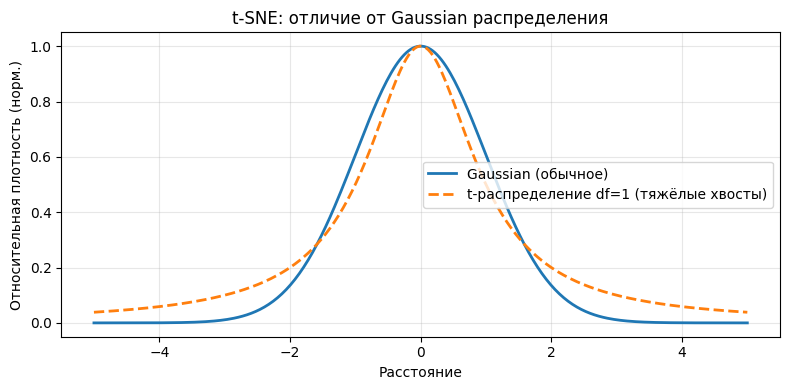

In [2]:
# Визуализация распределений для сравнения: Gaussian vs t-SNE

t = np.linspace(-5, 5, 300)
gauss = np.exp(-t**2 / 2)
student = 1 / (1 + t**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, gauss / gauss.max(), label='Gaussian (обычное)', linewidth=2)
ax.plot(t, student / student.max(), label='t-распределение df=1 (тяжёлые хвосты)', linewidth=2, linestyle='--')
ax.set_xlabel('Расстояние')
ax.set_ylabel('Относительная плотность (норм.)')
ax.set_title('t-SNE: отличие от Gaussian распределения')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

На графике видно: t-распределение с df=1 имеет существенно более тяжёлые хвосты по сравнению с гауссовым. На расстоянии 3 единицы плотность Стьюдента ещё около 0.1, а гауссовой плотности уже почти нет. Это ключевое свойство t-SNE: умеренно далёкие точки в исходном пространстве отображаются в большие расстояния в 2D. Кластеры получаются плотными и хорошо разделёнными без сжатия к центру.

## Блок 2

In [3]:
# Датасет 1: Digits
digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data.astype(float))
y_dig = digits.target
label_names_dig = {i: str(i) for i in range(10)}
print(f'Digits: {X_dig.shape}, классов: {len(np.unique(y_dig))}')

df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')
from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)


placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()
feature_cols = [col for col in df.columns if col not in ['status', 'status_enc', *object_cols]]

le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])
X_raw = df[feature_cols]
y = df['status_enc']
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_sub = X
y_sub = y

Digits: (1797, 64), классов: 10


Digits: 1797 образцов, 64 признака (пиксели 8x8), 10 сбалансированных классов цифр. Jobs Status: 300 образцов (с учетом бутстрепа для балансировки), ~15 признаков, 2 таргетных класса. Контраст важен: Digits — высокоразмерные данные с богатой нелинейной структурой, Jobs Status — все еще высокоразмерные данные, но между многими фичами есть сильная связь (прим. оценки в разные года обучения) и много категорных признаков.

## PCA: базовый метод

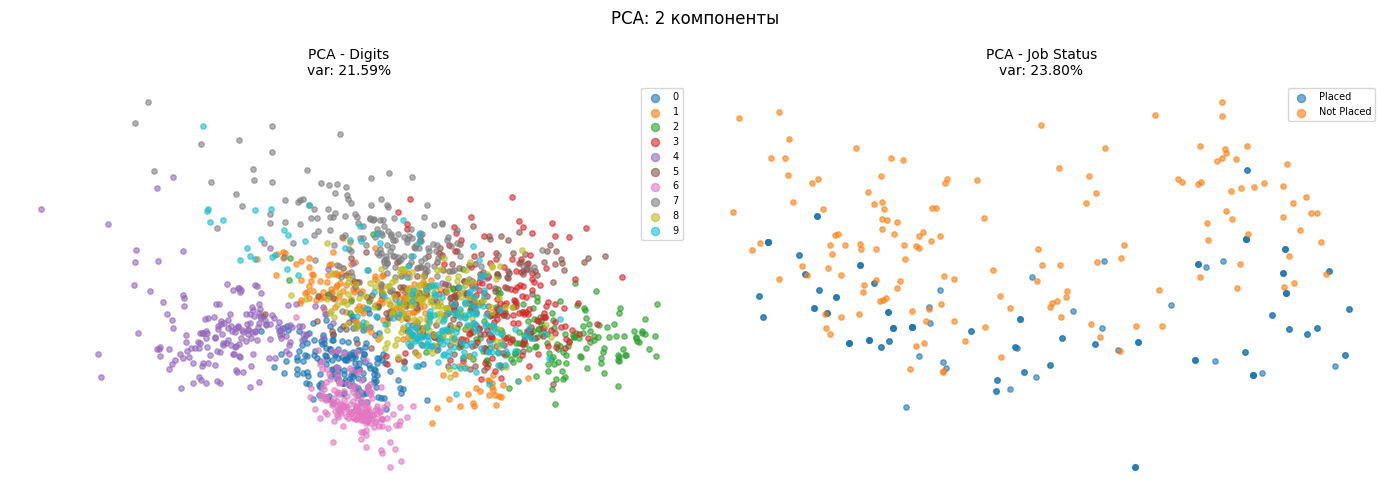

In [ ]:
def plot_2d(X2, y, label_names, title, ax):
    unique = np.unique(y)
    palette = sns.color_palette('tab10', len(unique))
    for i, lbl in enumerate(unique):
        mask = y == lbl
        ax.scatter(X2[mask, 0], X2[mask, 1],
            label=label_names[lbl], s=15, alpha=0.6, color=palette[i])
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    ax.legend(fontsize=7, markerscale=1.5, bbox_to_anchor=(1, 1))

pca_dig = PCA(n_components=2, random_state=42).fit(X_dig)
X_pca_dig = pca_dig.transform(X_dig)
pca = PCA(n_components=2, random_state=42).fit(X_sub)
X_pca = pca.transform(X_sub)

label_names = {0: 'Placed', 1: 'Not Placed'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_2d(X_pca_dig, y_dig, label_names_dig,
    f'PCA - Digits\nvar: {pca_dig.explained_variance_ratio_.sum():.2%}', axes[0])
plot_2d(X_pca, y_sub, label_names,
    f'PCA - Job Status\nvar: {pca.explained_variance_ratio_.sum():.2%}', axes[1])
plt.suptitle('PCA: 2 компоненты', fontsize=12)
plt.tight_layout()
plt.show()

PCA на Digits: две компоненты объясняют около 21% дисперсии 64-мерных данных. Кластеры сильно перекрываются — линейные проекции не могут отразить нелинейную структуру цифр. PCA на Job Status: две компоненты объясняют значительную долю дисперсии (около 50%). Кластеры лучше разделены за счёт малой исходной размерности.

## t-SNE: 2 компоненты

t-SNE Digits...
t-SNE Job Status...


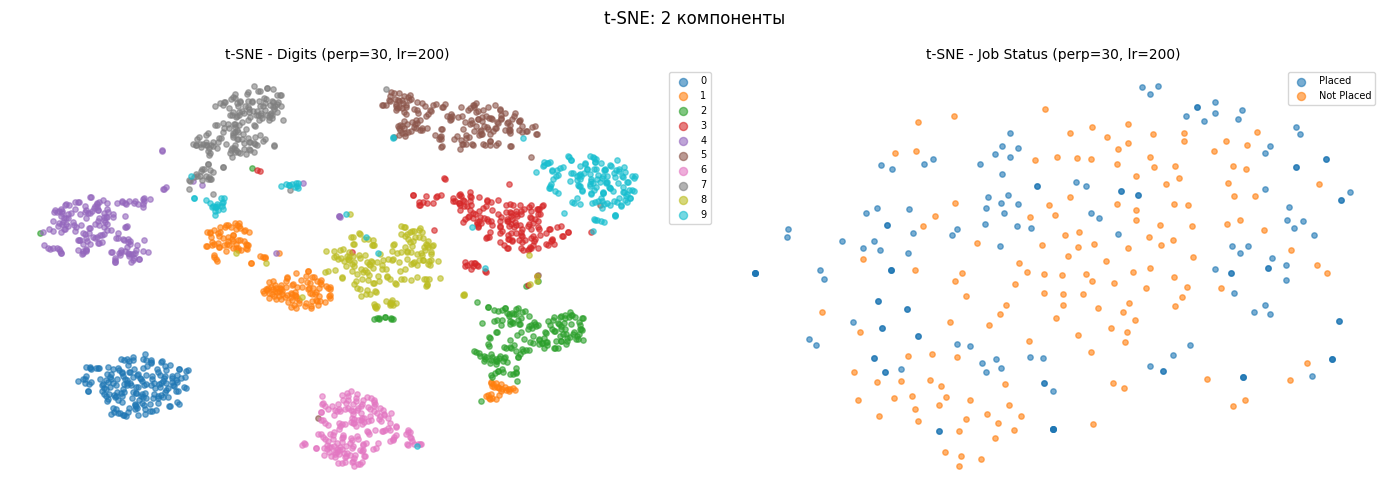

In [6]:
print('t-SNE Digits...')
X_tsne_dig = TSNE(n_components=2, perplexity=30, learning_rate=200,
    random_state=42, max_iter=1000).fit_transform(X_dig)
print('t-SNE Job Status...')
X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
    random_state=42, max_iter=1000).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_2d(X_tsne_dig, y_dig, label_names_dig, 't-SNE - Digits (perp=30, lr=200)', axes[0])
plot_2d(X_tsne, y_sub, label_names, 't-SNE - Job Status (perp=30, lr=200)', axes[1])
plt.suptitle('t-SNE: 2 компоненты', fontsize=12)
plt.tight_layout()
plt.show()

t-SNE на Digits формируются плотные изолированные кластеры цифр. Каждая цифра образует отдельную группу с минимальным перекрытием. Нелинейная структура раскрылась лучше PCA. t-SNE на Job Status  классы смешаны в общую массу, 6 признаков недостаточно, чтобы выделить локальные соседства

## Separation score

PCA (Digits): 1.931
t-SNE (Digits): 4.103
PCA (Job Status): 1.176
t-SNE (Job Status): 1.027


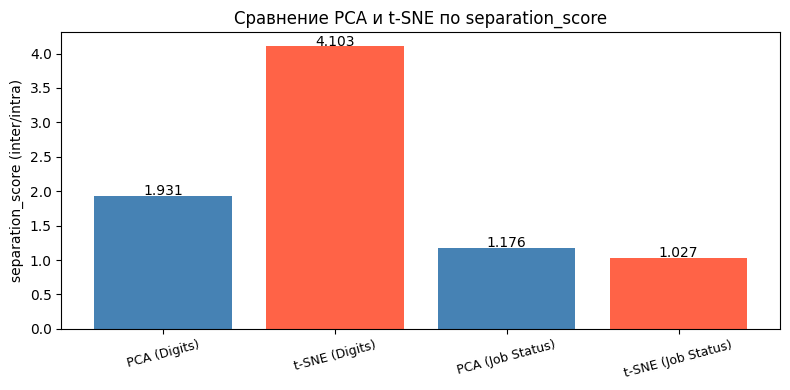

In [ ]:
def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    intra, inter = [], []
    classes = np.unique(y)
    for c in classes:
        mask = y == c
        idx_in = np.where(mask)[0]
        idx_out = np.where(~mask)[0]
        if len(idx_in) > 1:
            intra.append(D[np.ix_(idx_in, idx_in)].mean())
        if len(idx_out) > 0:
            inter.append(D[np.ix_(idx_in, idx_out)].mean())
    return np.mean(inter) / np.mean(intra) if np.mean(intra) > 0 else 0

scores = {
    'PCA (Digits)': separation_score(X_pca_dig, y_dig),
    't-SNE (Digits)': separation_score(X_tsne_dig, y_dig),
    'PCA (Job Status)': separation_score(X_pca, y_sub),
    't-SNE (Job Status)': separation_score(X_tsne, y_sub),
}
for name, sc in scores.items():
    print(f'{name}: {sc:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars = ax.bar(list(scores.keys()), list(scores.values()), color=colors)
ax.set_ylabel('separation_score (inter/intra)')
ax.set_title('Сравнение PCA и t-SNE по separation_score')
for bar, val in zip(bars, scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
        f'{val:.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15, fontsize=9)
plt.tight_layout()
plt.show()

На Digits t-SNE более чем в 2 раза превосходит . На моем датасете ситуация обратная PCA даёт ratio выше t-SNE

## Сетка гиперпараметров perplexity и learning_rate

Grid Digits...


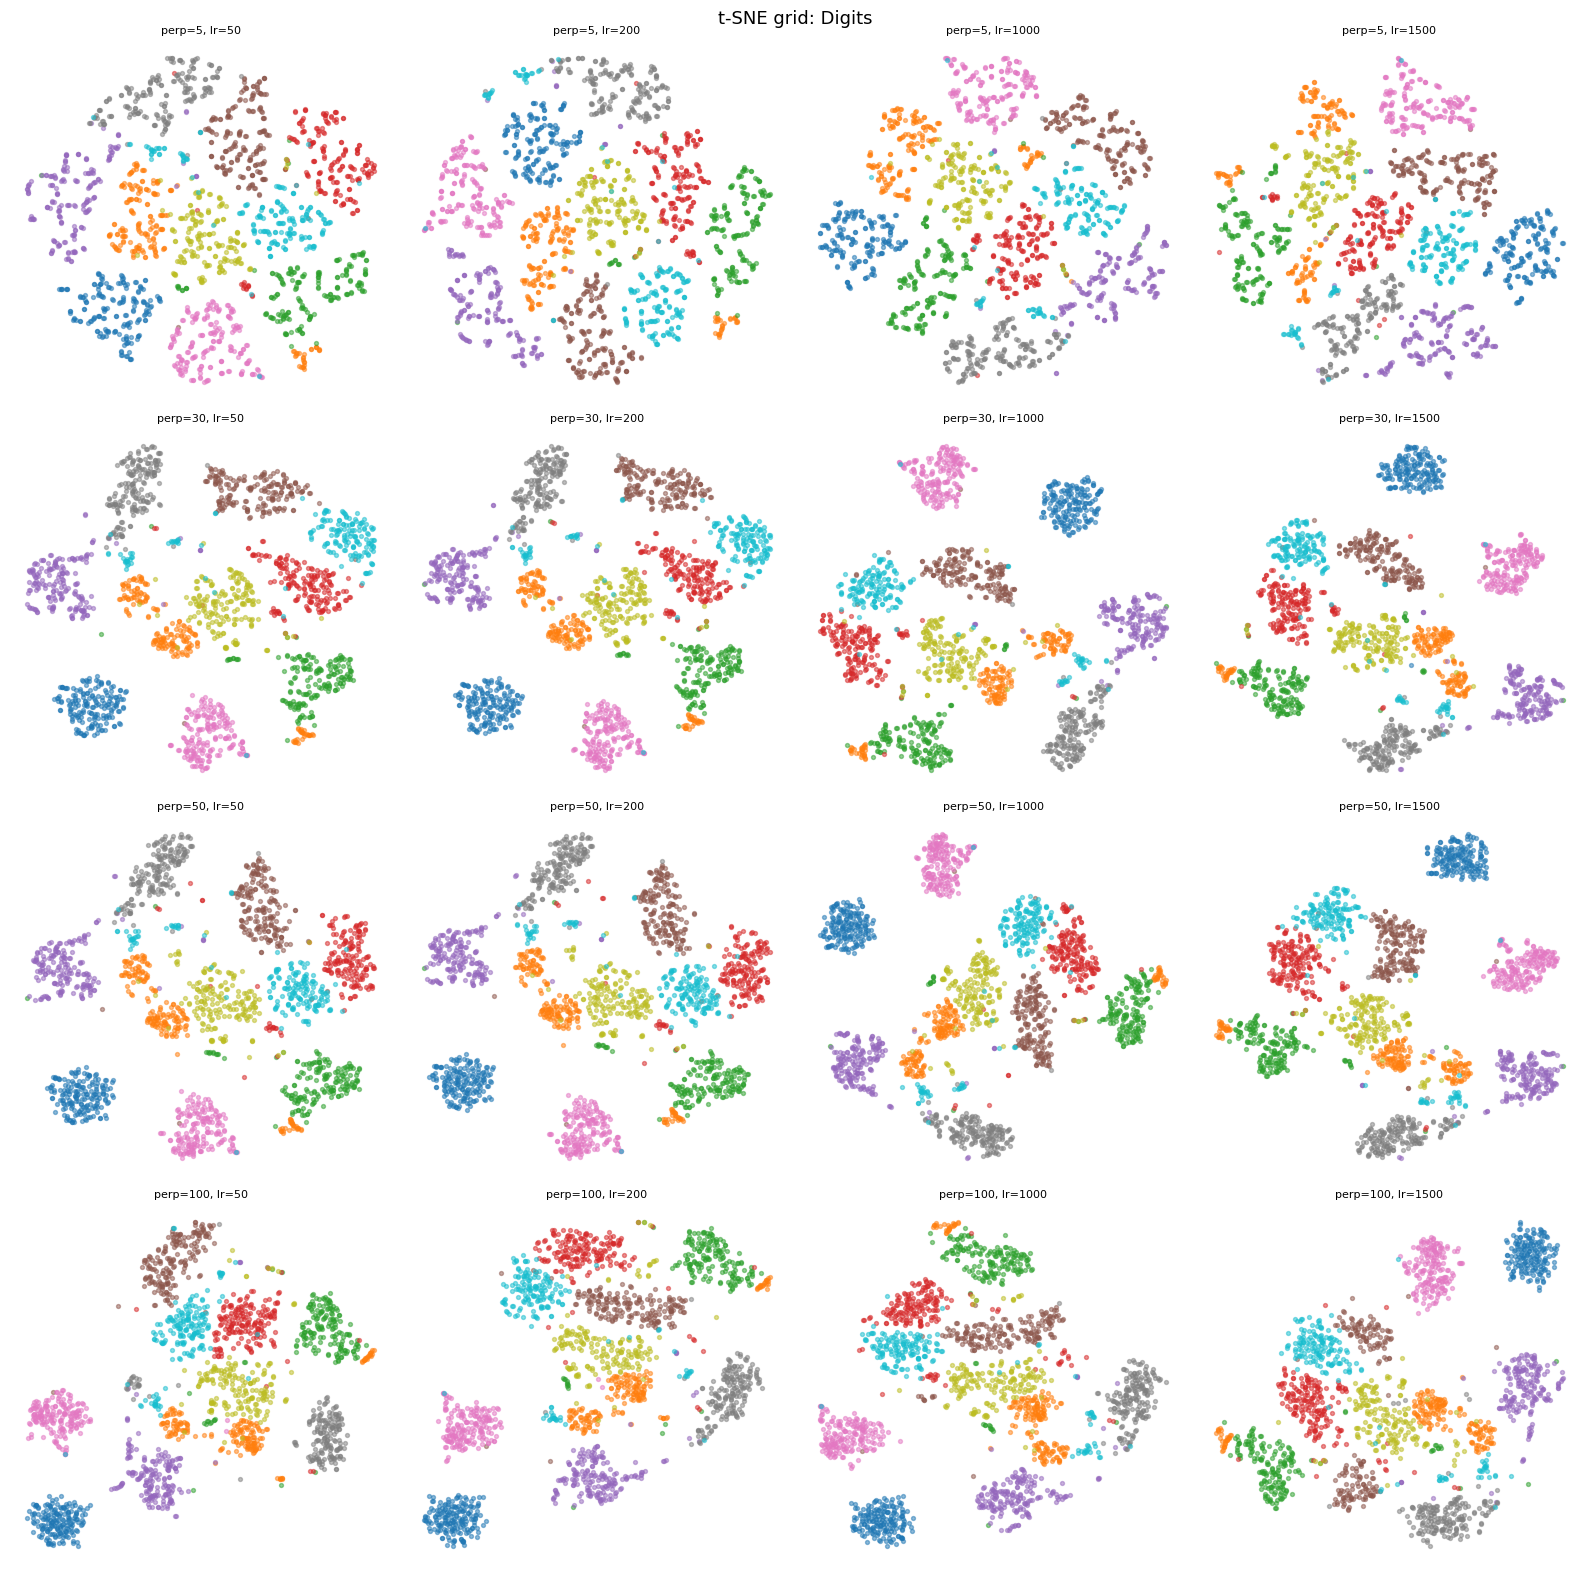

In [9]:
perplexities = [5, 30, 50, 100]
learning_rates = [50, 200, 1000, 1500]

def plot_tsne_grid(X, y, label_names, dataset_name):
    palette = sns.color_palette('tab10', len(np.unique(y)))
    fig, axes = plt.subplots(len(perplexities), len(learning_rates),
        figsize=(4 * len(learning_rates), 4 * len(perplexities)))
    for i, perp in enumerate(perplexities):
        for j, lr in enumerate(learning_rates):
            X2 = TSNE(n_components=2, perplexity=perp, learning_rate=lr,
                random_state=42, max_iter=500).fit_transform(X)
            ax = axes[i][j]
            for k, lbl in enumerate(np.unique(y)):
                mask = y == lbl
                ax.scatter(X2[mask, 0], X2[mask, 1],
                    s=8, alpha=0.5, color=palette[k])
            ax.set_title(f'perp={perp}, lr={lr}', fontsize=8)
            ax.axis('off')
    plt.suptitle(f't-SNE grid: {dataset_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

print('Grid Digits...')
plot_tsne_grid(X_dig, y_dig, label_names_dig, 'Digits')

для Digits оптимальный perplexity 30-50 кластеры цифр компактны и чётко разделены. При perplexity=5 кластеры дробятся на мелкие фрагменты. При perplexity=100 структура сглаживается, кластеры начинают сливаться. Learning rate 200-1000 даёт стабильный результат, при lr=50 оптимизация менее устойчива

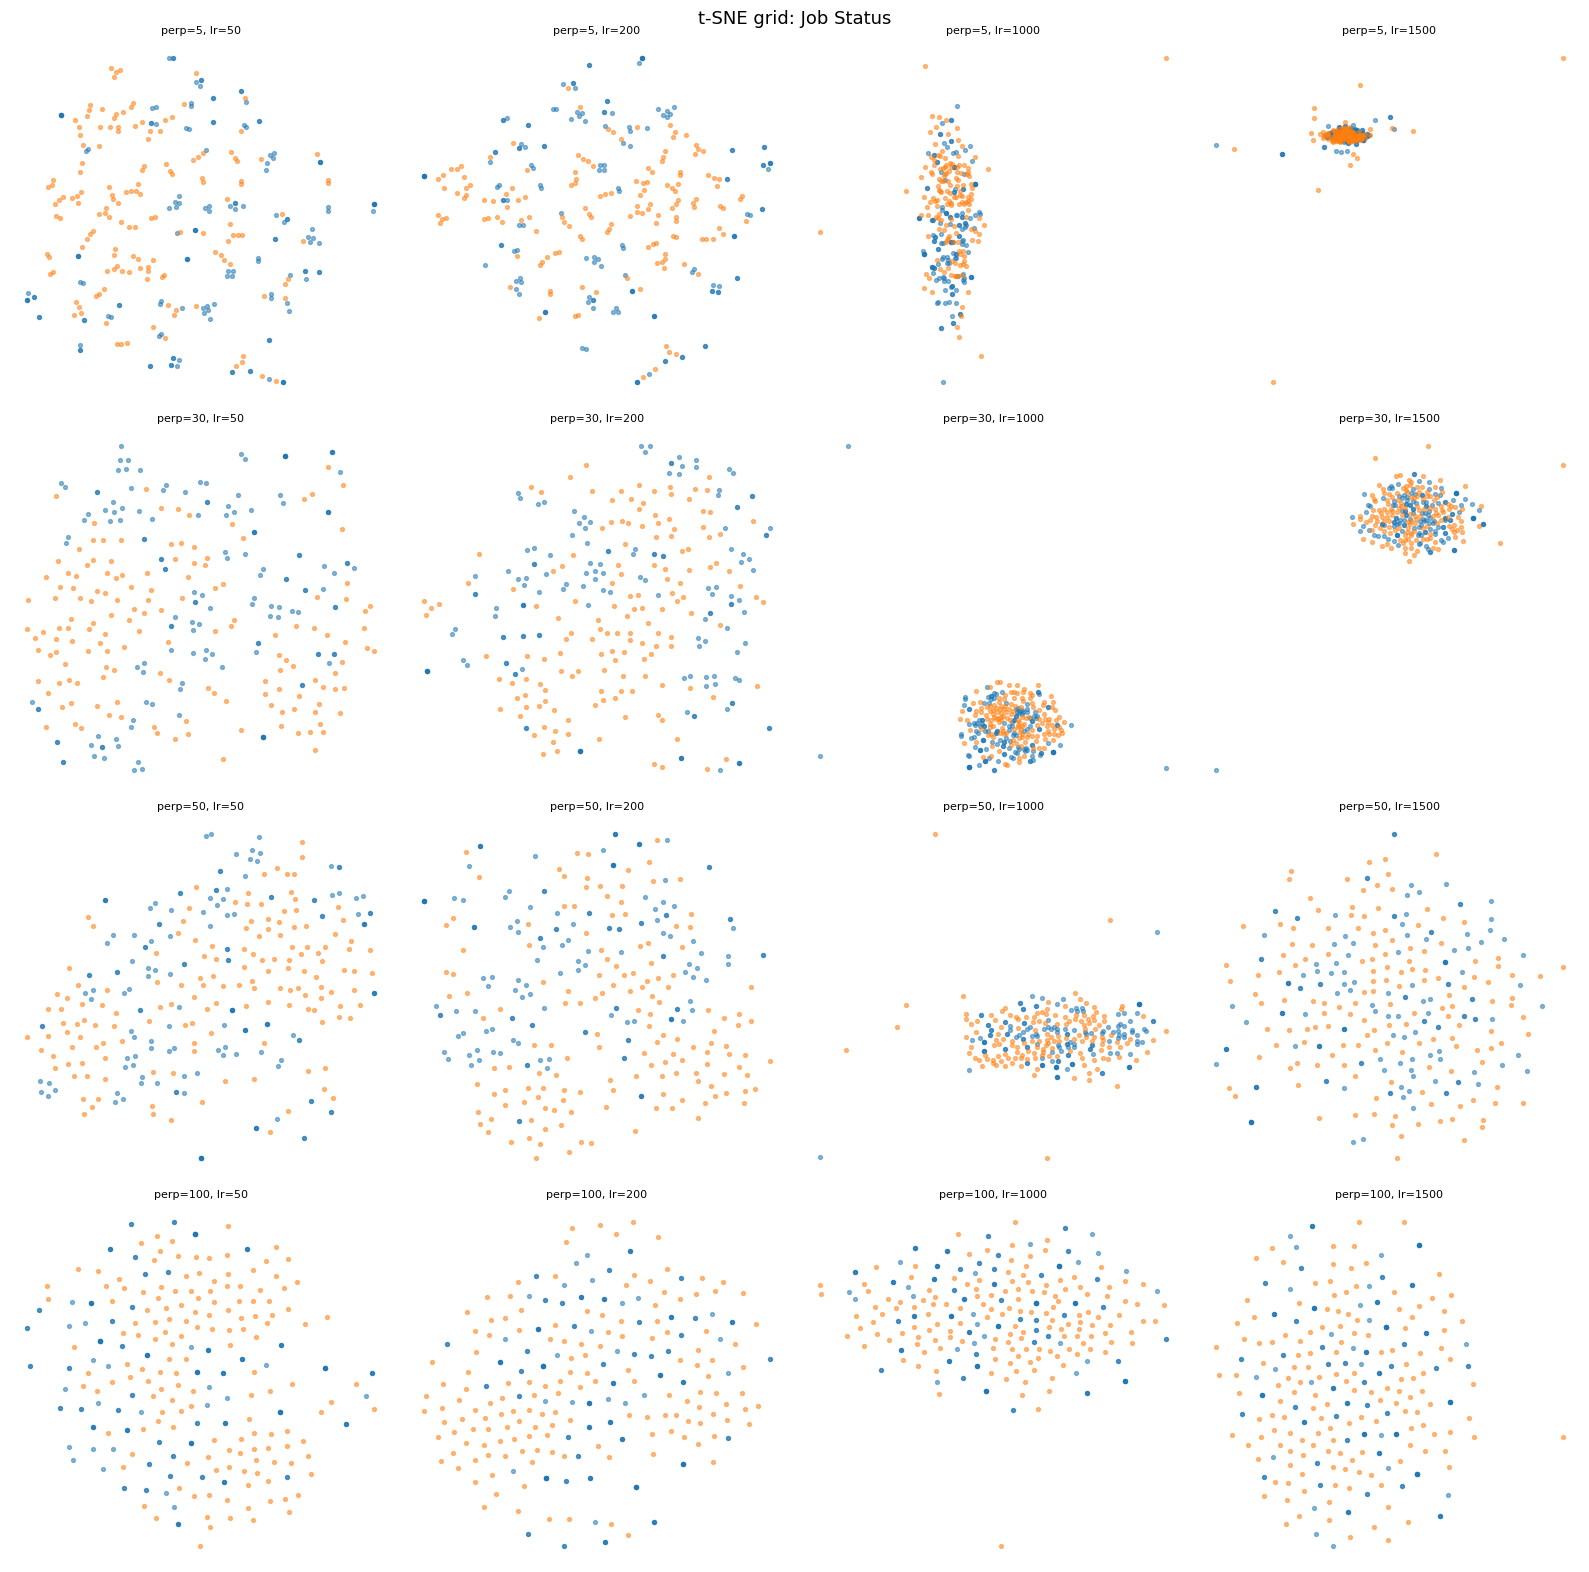

In [10]:
plot_tsne_grid(X_sub, y_sub, label_names, 'Job Status')

для статуса работы эффект perplexity выражен слабее, кластеры перекрыты при всех настройках. При perplexity=5 видна фрагментация. При perplexity=100 точки распределены почти равномерно. Высокий learning rate (1000-1500) даёт более компактные группы

## Анализ устойчивости PCA по числу компонент

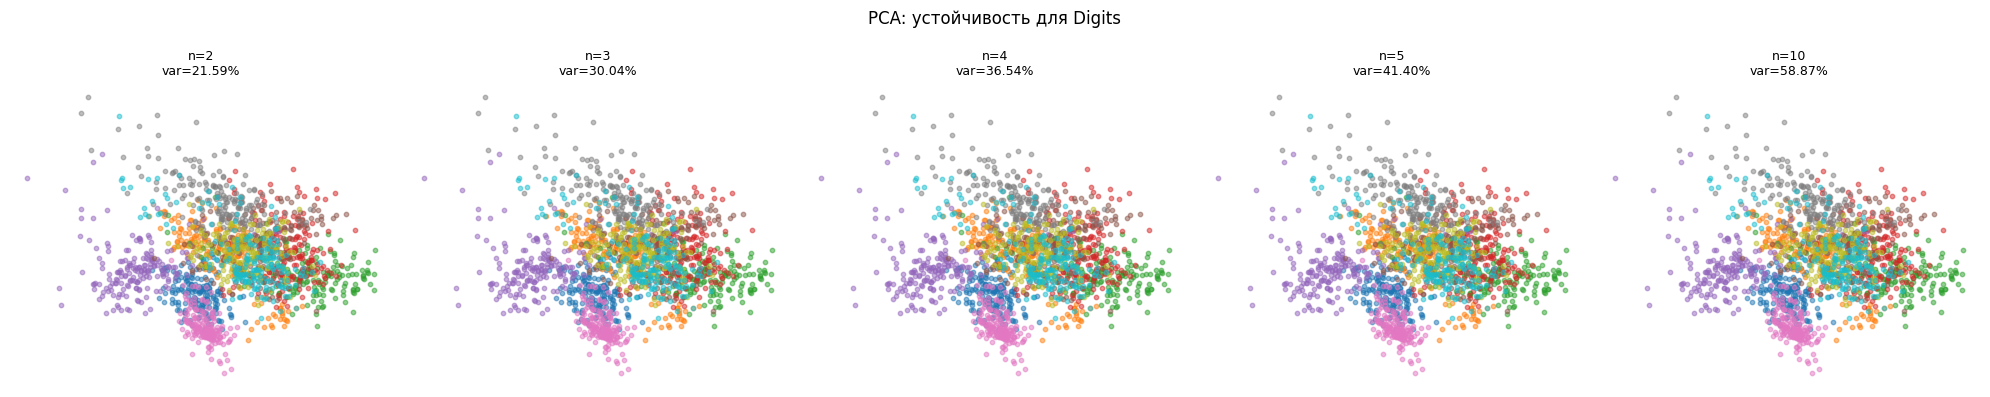

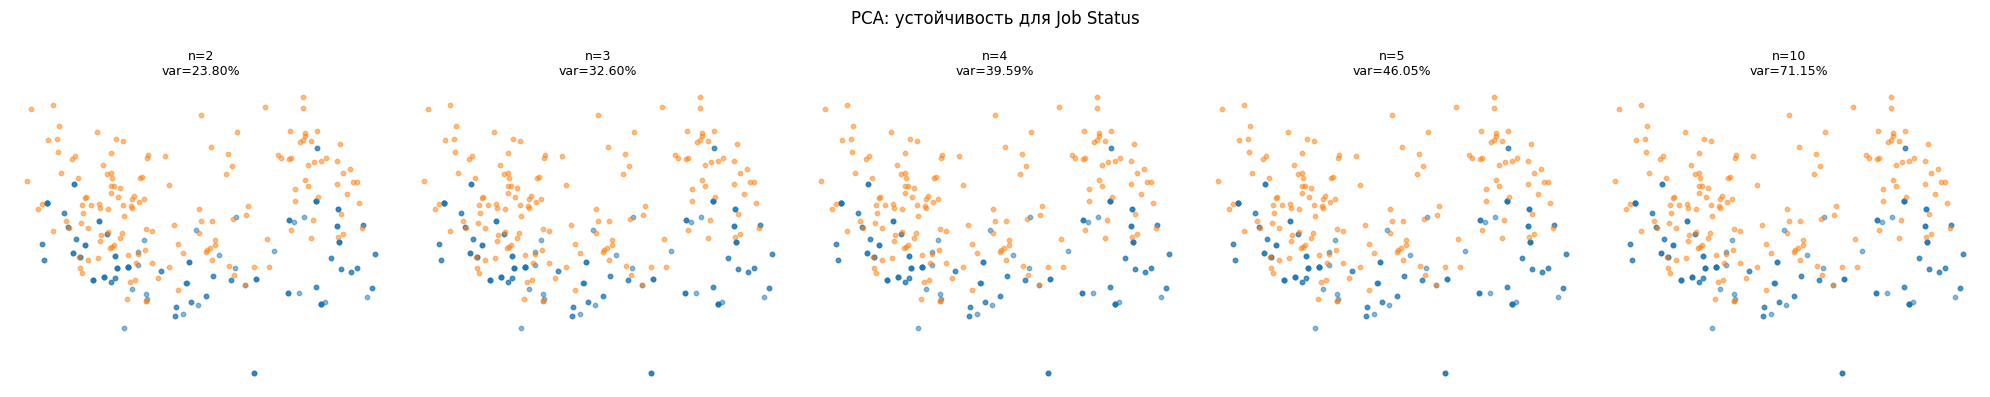

In [11]:
n_components_list = [2, 3, 4, 5, 10]

def plot_pca_stability(X, y, label_names, dataset_name):
    palette = sns.color_palette('tab10', len(np.unique(y)))
    max_components = min(X.shape[0], X.shape[1])
    valid_components = [n for n in n_components_list if n <= max_components]
    fig, axes = plt.subplots(1, len(valid_components),
        figsize=(4 * len(valid_components), 4))
    axes = np.atleast_1d(axes)
    for ax, n in zip(axes, valid_components):
        pca = PCA(n_components=n, random_state=42).fit(X)
        X2 = pca.transform(X)[:, :2]
        for k, lbl in enumerate(np.unique(y)):
            mask = y == lbl
            ax.scatter(X2[mask, 0], X2[mask, 1],
                s=10, alpha=0.5, color=palette[k])
        total_var = pca.explained_variance_ratio_.sum()
        ax.set_title(f'n={n}' + chr(10) + f'var={total_var:.2%}', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'PCA: устойчивость для {dataset_name}', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_pca_stability(X_dig, y_dig, label_names_dig, 'Digits')
plot_pca_stability(X_sub, y_sub, label_names, 'Job Status')

На Digits дисперсия медленно накапливается с ростом числа компонент данные имеют высокую внутреннюю размерность, 10 компонент покрывают только часть дисперсии. Структура кластеров на проекции не сильно меняется первые две компоненты уже захватывают основную вариацию. На статусе работы 3-4 компоненты объясняют большую часть дисперсии внутренняя размерность близка к исходной. Это согласуется с малой размерностью данных